# III. Áp dụng Canny cho các loại ảnh khác nhau
**Mục tiêu:** Kiểm tra độ bền vững (robustness) của Canny Edge Detector:
- **Ảnh nhiều nhiễu** (Gaussian, Salt & Pepper): Yêu cầu tiền xử lý (Blur, Median).
- **Ảnh độ tương phản thấp:** Yêu cầu Histogram Equalization nâng tương phản trước.
- **Ảnh nhiều chi tiết nhỏ:** Sử dụng Sharpening filter để mô phỏng hạt vân nhiễu.
- **Đánh giá Canny vs Sobel, Prewitt, Laplacian:** Kết hợp đánh giá định lượng bằng **PSNR** và **SSIM**. Canny thường vượt trội do thực hiện NMS làm mỏng viền.

---
🔻 **CHẠY CELL CODE DƯỚI ĐÂY ĐỂ THỰC THI TOÀN BỘ PHẦN III** 🔻

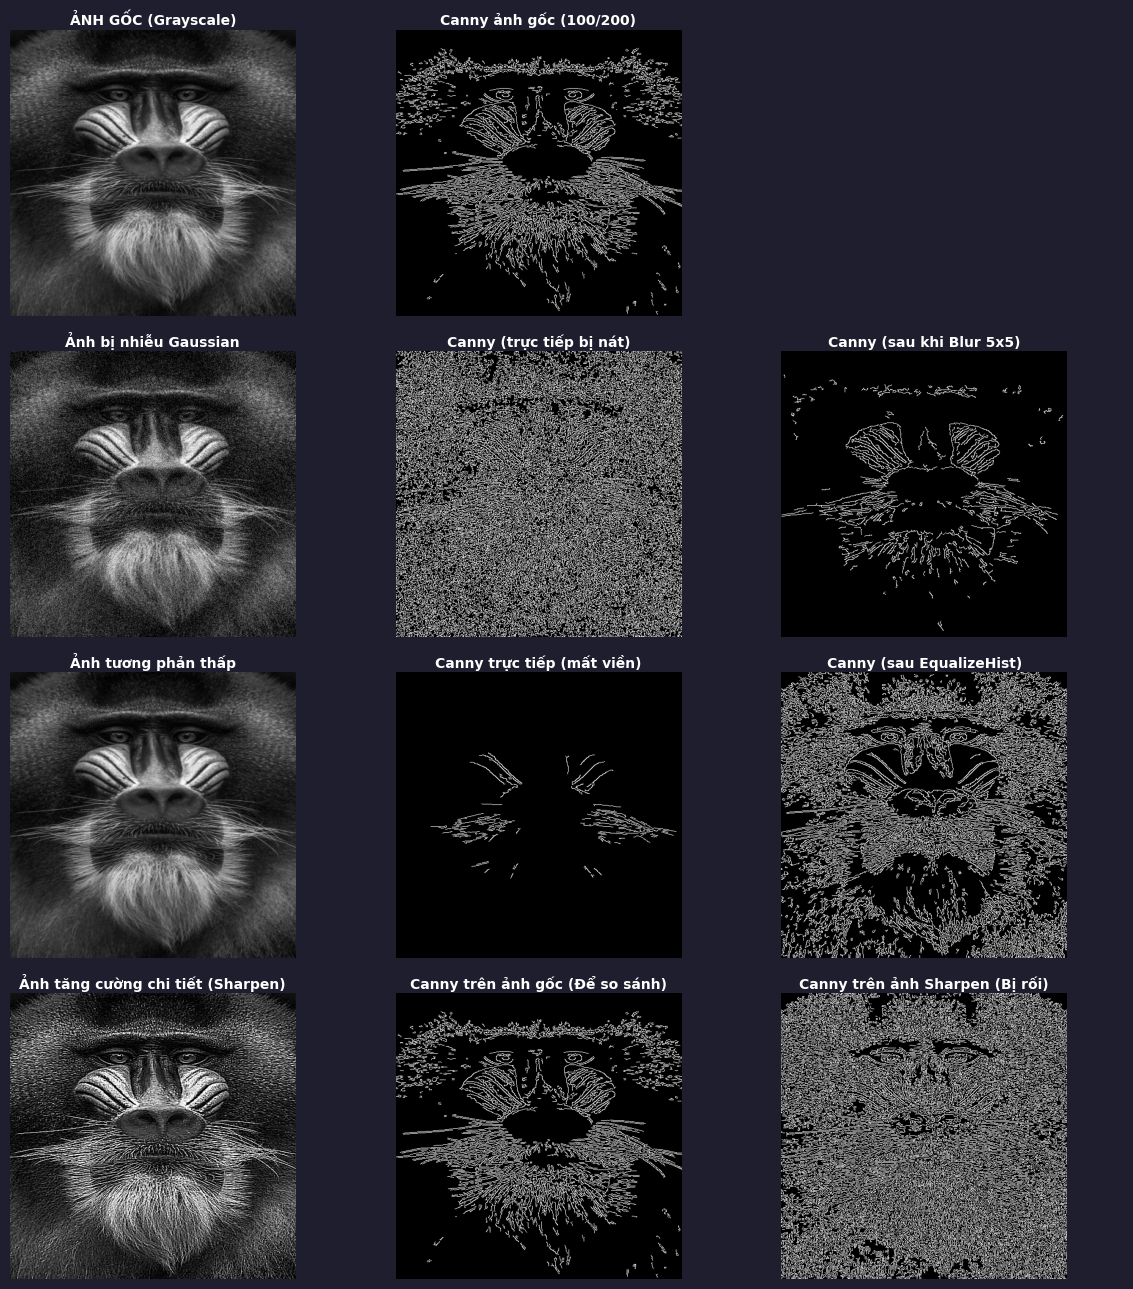

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.util import random_noise

BASE_DIR = Path.cwd().parent
INPUT_PATH = BASE_DIR / "input" / "lab_image.jpg"

if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy ảnh tại {INPUT_PATH}")

img_bgr = cv2.resize(cv2.imread(str(INPUT_PATH)), (512, 512), interpolation=cv2.INTER_AREA)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
gray_f = img_gray.astype(np.float64) / 255.0

def show(ax, img, title):
    ax.imshow(img, cmap="gray")
    ax.set_title(title, pad=4, fontsize=10, color="white")
    ax.axis("off")

fig_bg = "#1e1e2e"

T_LOWER = 100
T_UPPER = 200

fig, axes = plt.subplots(4, 3, figsize=(12, 13), facecolor=fig_bg)
normal_edge = cv2.Canny(img_gray, T_LOWER, T_UPPER)

show(axes[0, 0], img_gray, "ẢNH GỐC (Grayscale)")
show(axes[0, 1], normal_edge, f"Canny ảnh gốc ({T_LOWER}/{T_UPPER})")
axes[0, 2].axis("off") # Ẩn ô thứ 3 của hàng đầu tiên cho đỡ trống


# 1. TRƯỜNG HỢP ẢNH NHIỀU NHIỄU (Gaussian Noise)

noisy_img = np.uint8(np.clip(random_noise(gray_f, mode='gaussian', var=0.01) * 255, 0, 255))
noisy_edge = cv2.Canny(noisy_img, T_LOWER, T_UPPER)
# Qua bộ lọc Blur trước rồi mới canny ảnh nhiễu, nếu ko qua blur mà canny trực tiếp ảnh nhiễu ra bị nát ảnh
blurred_noisy = cv2.GaussianBlur(noisy_img, (5, 5), 0)
blurred_edge = cv2.Canny(blurred_noisy, T_LOWER, T_UPPER)

show(axes[1, 0], noisy_img, "Ảnh bị nhiễu Gaussian")
show(axes[1, 1], noisy_edge, "Canny trực tiếp (bị nát)")
show(axes[1, 2], blurred_edge, "Canny (sau khi Blur 5x5)")
# 2. TRƯỜNG HỢP ẢNH TƯƠNG PHẢN THẤP
low_contrast_img = np.uint8(img_gray.astype(np.float32) * 0.4 + 100)
low_contrast_edge = cv2.Canny(low_contrast_img, T_LOWER, T_UPPER)

# Canny kết hợp cân bằng Histogram tương tự ở trên
eq_img = cv2.equalizeHist(low_contrast_img)
eq_edge = cv2.Canny(eq_img, T_LOWER, T_UPPER)

show(axes[2, 0], low_contrast_img, "Ảnh tương phản thấp")
show(axes[2, 1], low_contrast_edge, f"Canny trực tiếp (mất viền)")
show(axes[2, 2], eq_edge, "Canny (sau EqualizeHist)")


# 3. TRƯỜNG HỢP ẢNH NHIỀU CHI TIẾT 

sharpen_kernel = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
detailed_img = cv2.filter2D(img_gray, -1, sharpen_kernel)
detailed_edge = cv2.Canny(detailed_img, T_LOWER, T_UPPER)

show(axes[3, 0], detailed_img, "Ảnh tăng cường chi tiết ")
show(axes[3, 1], normal_edge, "Canny trên ảnh gốc ")
show(axes[3, 2], detailed_edge, "Canny trên ảnh Sharpen ")

plt.tight_layout()
plt.show()